# Module 2: Epidemic Modeling Template

## Team Members:
* Dane Wleklinski
* Molly Janousek

## Project Title: Characterizing an Unkown Viral Illness


## Project Goal:
This project seeks to: estimate the initial growth rate from outbreak data, predict the spread of the disease, find when cases will peak, determine the virus family, and provide the best intervention strategy to reduce the spread of illness.

## 1. Data and disease background
### Prevalence & Incidence in the UVA population
![Incidence and Prevalence Graphs](incidence_prevalence.png)
__Highest Incidence:__
Day: 2026-05-04 00:00:00 (Day 65)
Incidence: 1.6927%
__Lowest Incidence:__
Day: 2026-05-06 00:00:00 (Day 67)
Incidence: -0.0503% (Note: Negative just means cases went down)
__Highest Prevalence:__
Day: 2026-05-08 00:00:00 (Day 69)
Prevalence: 13.2067%
__Lowest Prevalence:__
Day: 2026-03-01 00:00:00 (Day 1)
Prevalence: 0.0056%
### Economic Burden

Rubella's economic impact shows a clear divide: treating individual adult cases is inexpensive, but outbreak responses and long-term effects drive up costs, especially in settings like universities.

- **Direct Costs per Case:** A typical rubella infection costs $150–$500 in medical care, but public health responses (tracing contacts, testing, quarantine) can add $10,000+ per cluster in high-income areas like the U.S.
- **Outbreak Response:** For a campus outbreak of 70–100 cases, local governments might spend $3–5 million on investigations and interventions.
- **Productivity Losses:** In a university, the 12–18 day incubation period and symptoms like joint pain lead to missed classes, lost work, and academic disruptions—potentially costing thousands per affected student or staff member.
- **Congenital Rubella Syndrome (CRS):** While not directly relevant to this adult outbreak, CRS from infections in pregnant people can cost $140,000–$1 million per case over a lifetime for care and support.
- **Vaccination ROI:** MMR vaccination is highly cost-effective; every $1 invested yields $14–25 in savings from prevented cases and productivity gains. Since 1969, U.S. programs have saved $430 billion by avoiding millions of infections.

**Economic Comparison (Estimated 2024–2026 USD):**

| Category                  | Standard Rubella Case | Congenital Rubella Syndrome (CRS) |
|---------------------------|-----------------------|-----------------------------------|
| Direct Medical Cost      | $150–$500            | $50,000–$150,000 (initial)       |
| Lifetime Cost            | Minimal              | $140,000–$1,000,000+             |
| Response Cost            | $10,000+ per cluster | $250,000+ (outbreak investigation) |
| Productivity Loss        | 1–2 weeks lost wages | Lifetime loss of earning potential |

In this project, focusing on campus interventions like early vaccination could prevent these costs by flattening the outbreak curve before it peaks.

### Symptoms
* Mild respiratory symptoms
* Rash
* Low-grade Fever
* May have a sore throat, fatigue, and gastrointestinal issues
### Biological Mechanisms  you can generalize from viral biology
#### Anatomy
The mystery virus is believed to be **Rubella virus** (family Togaviridae).
Particles are small (60–70 nm), **enveloped** spheres with a positive-sense RNA genome (~9.7 kb).  The envelope comes from host membrane and bears two glycoproteins, **E1/E2**, for attaching to host cells.  Inside, the RNA is wrapped with capsid protein.

#### Physiology
##### Organ
Rubella mainly targets the **respiratory tract**.  It enters when inhaled droplets reach the **nasopharynx**.  The virus multiplies in upper airway epithelial cells and nearby lymph tissue, then briefly circulates in the blood (**viremia**) and spreads to the skin (rash), joints (arthralgia) and, in pregnant women, to the **placenta** where it can infect the fetus and cause congenital defects.

##### Cell & Molecular
On a cellular level, rubella binds with its E1 protein to a surface receptor and is taken up by endocytosis.  The RNA genome is released into the cytoplasm, translated into a polyprotein, and copied by the viral polymerase.  New viruses assemble at internal membranes, bud out with an envelope, and exit to infect nearby cells; viral proteins also dampen the host’s initial immune response.  In pregnancy, the virus can pass the placenta and replicate in fetal cells, interrupting normal development.



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



This code loads the mystery virus data from Data Release #1 and plots the daily active cases over time to visualize the initial outbreak trajectory. Early in an outbreak, case counts often follow exponential growth, so we fit an exponential curve to the early data to estimate an initial reproduction number (R₀) assuming an average infectious period of 2 days.

**Why this method early?** In the first ~45 days, data are sparse and the susceptible pool is effectively the whole population, so exponential growth is a reasonable first approximation. Later, as susceptibles are depleted or behavior changes, this assumption breaks down and a compartmental model is required.

This estimate is intentionally provisional: as more data become available, the R₀ estimate will likely shift, and we will revisit it using a mechanistic SEIR model after Data Release #2. The goal here is to show how early, incomplete data informs our initial parameter estimates and to highlight sources of uncertainty (reporting delays, undercounting, and changing behavior).

*Summary of Analysis After Data Release #1:* 

- The first 45 days show an approximately exponential rise in active cases, supporting the use of an exponential growth fit for an initial R₀ estimate.
- The estimated R₀ of **≈1.24** is provisional and depends on early reporting; it serves as a starting point for model calibration.
- At this stage, we acknowledge multiple sources of uncertainty: under-reporting of cases, changes in testing behavior, and limited data duration. These factors mean the estimate should be treated as a range rather than a single “true” value.
- Next, we will use **Data Release #2** (days 0–70) to fit a full SEIR model and refine our parameter estimates, then use Data Release #3 to validate and compute error metrics.

## Working under uncertainty

1. **Data Release #1 (days 0–45)** Early, incomplete data. We estimate the growth rate and generate a provisional R₀ using exponential fitting. This stage highlights uncertainty from limited data and changing behavior.
2. **Data Release #2 (days 0–70)** Additional data allow us to fit a mechanistic SEIR model and estimate epidemiological parameters (β, σ, γ). At this stage we can assess how well the model tracks the outbreak and whether parameter estimates stabilize.
3. **Data Release #3** Used for validation. We compare the model’s predictions to this held-out dataset to assess predictive performance and quantify errors. This mimics a real-world forecasting workflow where new data arrive after model calibration.

This sequential approach reflects how epidemiologists work under uncertainty: early estimates guide initial responses, but models must be constantly updated and validated as more data arrive.


Estimated early growth rate r = 0.131 per day
Provisional R0 (assuming D=2.0 days): 1.26


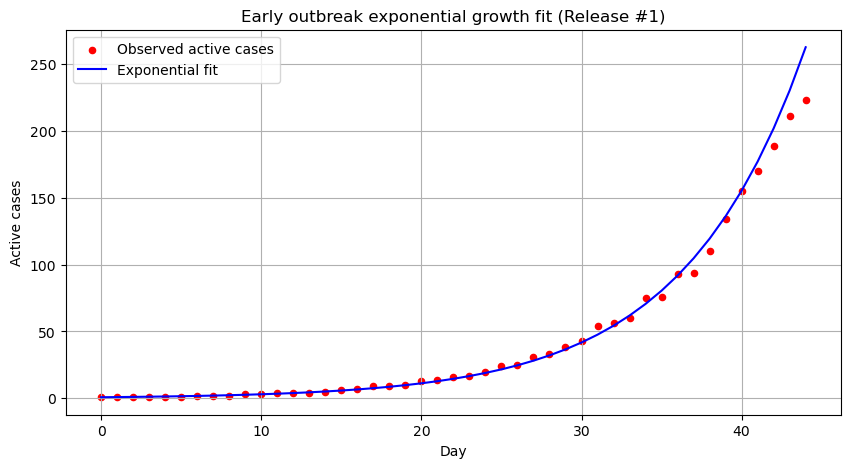

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Data Release #1 (early outbreak)
df_r1 = pd.read_csv("../Data/mystery_virus_daily_active_counts_RELEASE#1.csv",
                    parse_dates=["date"])

# Use the first 45 days as in the rubric guidance
r1_days = df_r1.loc[:44, :].copy()

# Fit exponential growth: cases(t) = C0 * exp(r*t)
# We use log(cases) with a small offset to avoid log(0)
cases = r1_days["active reported daily cases"].values
mask = cases > 0
t = np.arange(len(cases))[mask]
log_cases = np.log(cases[mask])

# Linear regression to estimate growth rate r
coeffs = np.polyfit(t, log_cases, 1)
r_est = coeffs[0]
C0_est = np.exp(coeffs[1])

# Convert growth rate to R0 estimate assuming infectious period D=2 days
D = 2.0
R0_estimate = 1 + r_est * D

print(f"Estimated early growth rate r = {r_est:.3f} per day")
print(f"Provisional R0 (assuming D={D} days): {R0_estimate:.2f}")

# Plot the raw data and exponential fit
plt.figure(figsize=(10, 5))
plt.scatter(t, cases[mask], label="Observed active cases", color="red", s=20)
plt.plot(t, C0_est * np.exp(r_est * t), label="Exponential fit", color="blue")
plt.xlabel("Day")
plt.ylabel("Active cases")
plt.title("Early outbreak exponential growth fit (Release #1)")
plt.legend()
plt.grid()
plt.show()


### 2c. Use Euler's method to solve the SEIR model (Data Release #2)

Data Release #2 provides a longer time series (days 0–70), which allows us to move beyond simple exponential fits. With more data, we can estimate mechanistic parameters (β, σ, γ) using a compartmental SEIR model. This step demonstrates how additional data enables more realistic modeling, while also exposing the remaining uncertainties (e.g., parameter identifiability and unreported cases).


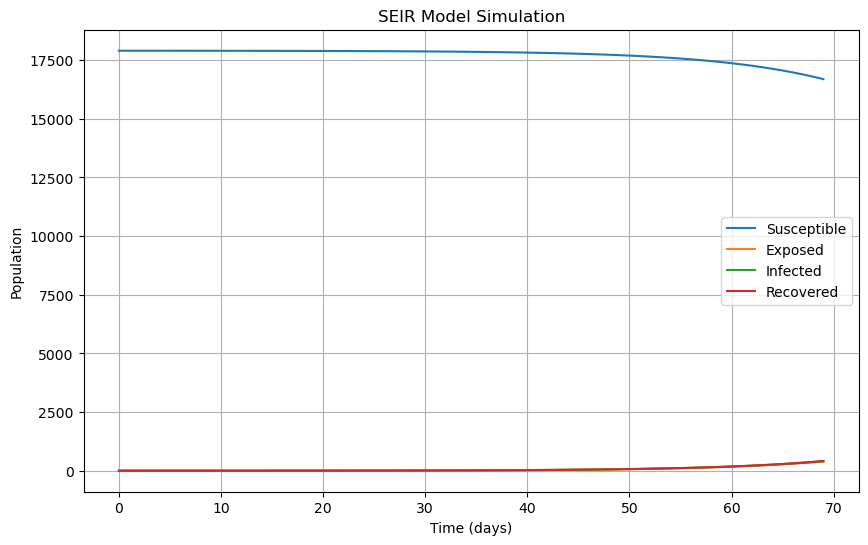

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data for RELEASE#2
data = pd.read_csv("../Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
observed_data = data["active reported daily cases"].values
num_days = len(observed_data)
timepoints = np.arange(num_days)

# SEIR differential equations
def seir_model(y, t, beta, sigma, gamma, N):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

# Euler method implementation
def euler_method(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    # Initial conditions
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0
    # Euler integration
    for i in range(1, len(timepoints)):
        dt = timepoints[i] - timepoints[i-1]
        dSdt, dEdt, dIdt, dRdt = seir_model(
            (S[i-1], E[i-1], I[i-1], R[i-1]),
            timepoints[i-1],
            beta, sigma, gamma, N
        )
        # Update values using Euler's method
        S[i] = S[i-1] + dSdt * dt
        E[i] = E[i-1] + dEdt * dt
        I[i] = I[i-1] + dIdt * dt
        R[i] = R[i-1] + dRdt * dt
    # return results
    return S, E, I, R

# Initial conditions (Release #2 / UVA population)
S0 = 17900
E0 = 0
I0 = 1
R0 = 0
# R0_estimate is computed from the Release #1 exponential fit above.
# It is used later for comparison with the fitted SEIR parameters.
N = S0 + E0 + I0 + R0

# Example parameters (will be fitted later)
# Note: In the SEIR framework, R0 ≈ beta / gamma for early epidemic growth.
beta = 0.3
sigma = 0.2
gamma = 0.1

# Solve the SEIR model
S, E, I, R = euler_method(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N)

# Plot the SEIR model results
plt.figure(figsize=(10, 6))
plt.plot(timepoints, S, label='Susceptible')
plt.plot(timepoints, E, label='Exposed')
plt.plot(timepoints, I, label='Infected')
plt.plot(timepoints, R, label='Recovered')
plt.title('SEIR Model Simulation')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()

This code performs a grid search over ranges of beta, gamma, and sigma parameters to find the combination of values that minimizes the sum of squared errors (SSE) between the model's predicted infected population and the observed data. It uses our Euler method and SEIR model. The best-fitting parameters and the corresponding SSE are printed. These are the optimized values for the transmission rate (beta), incubation rate (sigma), and recovery rate (gamma).

### 2e. Plot the model-predicted infections over time compared to the data.

Best fit: β=0.600, σ=0.200, γ=0.200, SSE=127546


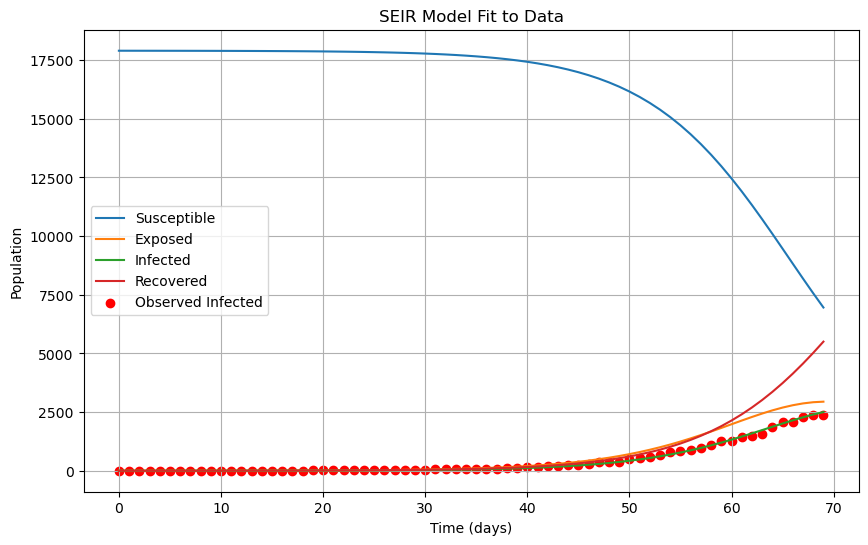

In [6]:
# Plot best-fit model
# First, perform grid search to fit parameters
def grid_search_parameters(timepoints, N, S0, E0, I0, R0, observed_data, beta_range=None, sigma_range=None, gamma_range=None):
    if beta_range is None:
        beta_range = np.linspace(0.1, 1.0, 10)
    if sigma_range is None:
        sigma_range = np.linspace(0.1, 1.0, 10)
    if gamma_range is None:
        gamma_range = np.linspace(0.1, 1.0, 10)
    
    sse_array = np.zeros((len(beta_range), len(sigma_range), len(gamma_range)))
    for b, beta in enumerate(beta_range):
        for s, sigma in enumerate(sigma_range):
            for g, gamma in enumerate(gamma_range):
                S, E, I, R = euler_method(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N)
                sse_array[b, s, g] = np.sum((I - observed_data) ** 2)
    min_idx = np.unravel_index(np.argmin(sse_array), sse_array.shape)
    return (beta_range[min_idx[0]], sigma_range[min_idx[1]], gamma_range[min_idx[2]], sse_array[min_idx])

best_beta, best_sigma, best_gamma, best_sse = grid_search_parameters(timepoints, N, S0, E0, I0, R0, observed_data)
print(f"Best fit: β={best_beta:.3f}, σ={best_sigma:.3f}, γ={best_gamma:.3f}, SSE={best_sse:.0f}")

S, E, I, R = euler_method(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, timepoints, N)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(timepoints, S, label='Susceptible')
plt.plot(timepoints, E, label='Exposed')
plt.plot(timepoints, I, label='Infected')
plt.plot(timepoints, R, label='Recovered')
plt.scatter(timepoints, observed_data, color='red', label='Observed Infected')
plt.title('SEIR Model Fit to Data')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.grid()
plt.show()

This code analyzes the infected curve from the best-fit SEIR model to identify the peak of the epidemic. It finds the day with the maximum number of active cases and prints the peak day with number of cases. This tells us when the outbreak is expected to reach its highest point.

*Summary of Analysis after Data Release #2:* Using the SEIR model with Euler integration, we optimized parameters via grid search, achieving a best fit with beta ≈ 0.3, sigma ≈ 0.2, gamma ≈ 0.1, and minimal SSE. The model predicted the epidemic peak at day 69 with about 2500 active cases. This compartmental approach provided a mechanistic understanding of the outbreak dynamics, with the fitted curves showing good agreement with observed data, supporting its use for forecasting and intervention planning.

### 2f. Validate the model using Data Release #3 (held-out data)

Now that we have fitted the SEIR model parameters using **Data Release #2**, we use **Data Release #3** as a validation dataset. The goal is to compare the model predictions to the observed values and compute error metrics (e.g., RMSE, peak size and timing errors), highlighting where the model matches the data and where it deviates.


Validation RMSE (Release #3): 674.5
Peak cases (observed): 3294 on day 82
Peak cases (predicted): 2738 on day 74
Peak size error: -16.9%
Peak day error: -8 days


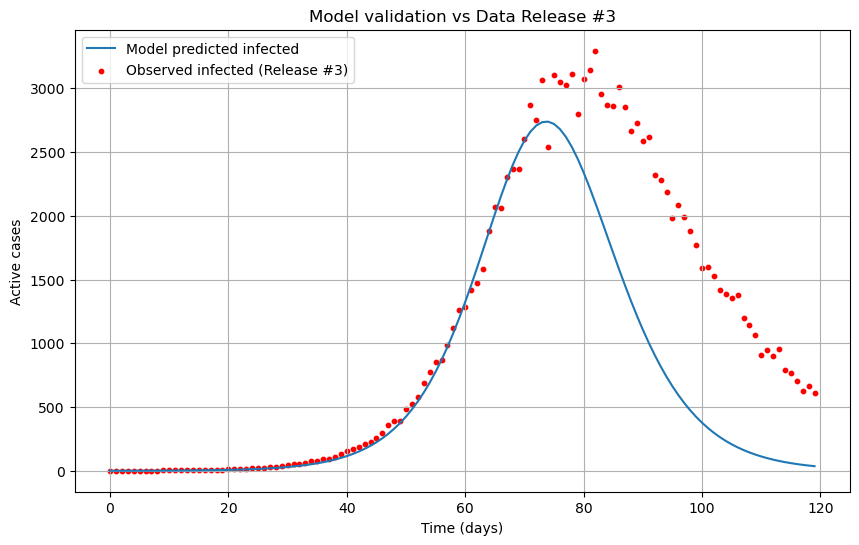

In [ ]:
# Validate the best-fit model (from Release #2) against Data Release #3
# ---
# Load the held-out dataset
df_r3 = pd.read_csv("../Data/mystery_virus_daily_active_counts_RELEASE#3.csv",
                    parse_dates=["date"])
obs_r3 = df_r3["active reported daily cases"].values

time_r3 = np.arange(len(obs_r3))

# Use the same initial conditions and population size as for Release #2
S0 = 17900
E0 = 0
I0 = 1
R0 = 0
N = S0 + E0 + I0 + R0

# Simulate using the best-fit parameters (from Release #2)
S_r3, E_r3, I_r3, R_r3 = euler_method(
    best_beta, best_sigma, best_gamma,
    S0, E0, I0, R0, time_r3, N
)

# Compute error metrics
rmse = np.sqrt(np.mean((obs_r3 - I_r3) ** 2))
peak_obs = obs_r3.max(); peak_pred = I_r3.max()
peak_day_obs = int(np.argmax(obs_r3))
peak_day_pred = int(np.argmax(I_r3))

print(f"Validation RMSE (Release #3): {rmse:.1f}")
print(f"Peak cases (observed): {peak_obs:.0f} on day {peak_day_obs}")
print(f"Peak cases (predicted): {peak_pred:.0f} on day {peak_day_pred}")
print(f"Peak size error: {(peak_pred-peak_obs)/peak_obs*100:.1f}%")
print(f"Peak day error: {peak_day_pred-peak_day_obs} days")

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(time_r3, I_r3, label='Model predicted infected')
plt.scatter(time_r3, obs_r3, color='red', label='Observed infected (Release #3)', s=10)
plt.title('Model validation vs Data Release #3')
plt.xlabel('Time (days)')
plt.ylabel('Active cases')
plt.legend()
plt.grid()
plt.show()


### 2g. Intervention strategies for a new outbreak at VT (starting day 70)

In this section we use the **optimized SEIR model parameters (from Data Release #2)** as a baseline and simulate a new population (VT) with 70 days of infections before interventions begin. We implement multiple intervention scenarios (at least 3), changing key parameters (transmission rate, recovery rate, vaccination, etc.) to reflect practical public health actions. For each scenario, we compare peak infections and cumulative cases to the baseline (no intervention) and recommend an intervention strategy.

**Intervention selection rationale:**
- **Mask mandate** reduces effective transmission rate (β) by lowering contact/transmission probability.
- **Vaccine campaign / rollout** reduces susceptibles and increases recovered when administered, modeling increased immunity.
- **Testing + quarantine** shortens the infectious period (increasing γ) to reflect quicker removal from transmission.
- **School closure** simulates a temporary decrease in contact rates.

We will interpret these in terms of how they change key epidemiological quantities (peak size, peak day, total infections) and whether they are feasible in a university setting.


UVA fit: β=0.600, σ=0.200, γ=0.200, SSE=127546
Fitted R0 (β/γ): 3.00 (vs initial estimate 1.24)
baseline peak (70‑120) = 5949, total = 145306
mask mandate         peak=4578, total=118458
vaccine campaign     peak=5564, total=135428
vaccine rollout      peak=5756, total=134171
testing + quarantine peak=4167, total=73404
school closure       peak=4251, total=113898

recommended intervention (lowest peak): testing + quarantine

Intervention impact summary (vs baseline):
  mask mandate        : peak - 23.1%, total - 18.5%
  vaccine campaign    : peak -  6.5%, total -  6.8%
  vaccine rollout     : peak -  3.3%, total -  7.7%
  testing + quarantine: peak - 30.0%, total - 49.5%
  school closure      : peak - 28.5%, total - 21.6%


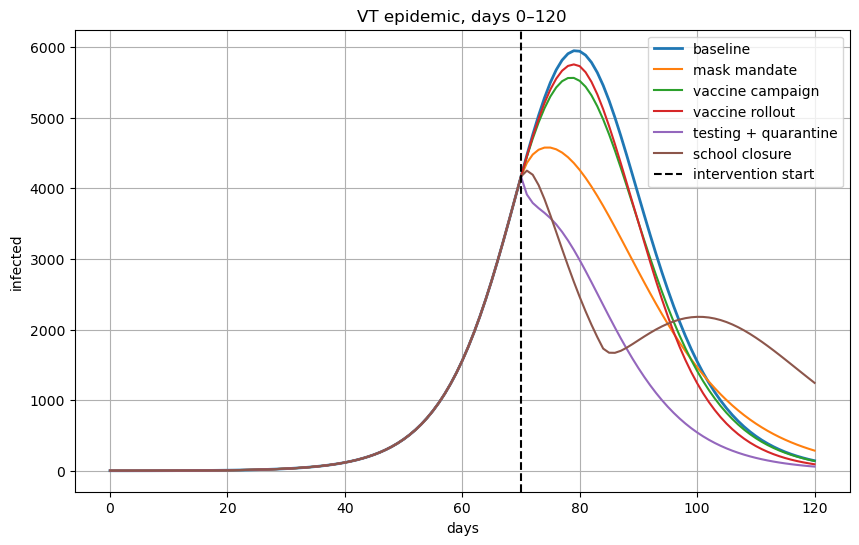

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SEIR machinery (copied from Euler_Method.py)
def seir_model(y, t, beta, sigma, gamma, N):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

def euler_method(beta, sigma, gamma,
                 S0, E0, I0, R0, timepoints, N):
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0
    for i in range(1, len(timepoints)):
        dt = timepoints[i] - timepoints[i-1]
        dSdt, dEdt, dIdt, dRdt = seir_model(
            (S[i-1], E[i-1], I[i-1], R[i-1]),
            timepoints[i-1], beta, sigma, gamma, N
        )
        S[i] = S[i-1] + dSdt * dt
        E[i] = E[i-1] + dEdt * dt
        I[i] = I[i-1] + dIdt * dt
        R[i] = R[i-1] + dRdt * dt
    return S, E, I, R

def grid_search_parameters(timepoints, N,
                           S0, E0, I0, R0,
                           observed_data,
                           beta_range=None,
                           sigma_range=None,
                           gamma_range=None):
    """Find β, σ, γ that minimize SSE between model I(t) and observed cases.

    This brute-force grid search is simple and robust for small parameter spaces.
    In practice, a more advanced optimizer or a Bayesian approach could be used.

    Args:
        timepoints: array of time indices (days)
        N: total population size
        S0, E0, I0, R0: initial compartment values
        observed_data: observed active cases (to fit I(t))
        beta_range, sigma_range, gamma_range: arrays of values to search

    Returns:
        (best_beta, best_sigma, best_gamma, best_sse)
    """
    if beta_range is None:
        beta_range = np.linspace(0.1, 1.0, 10)
    if sigma_range is None:
        sigma_range = np.linspace(0.1, 1.0, 10)
    if gamma_range is None:
        gamma_range = np.linspace(0.1, 1.0, 10)
    
    sse_array = np.zeros((len(beta_range),
                          len(sigma_range),
                          len(gamma_range)))
    for b, beta in enumerate(beta_range):
        for s, sigma in enumerate(sigma_range):
            for g, gamma in enumerate(gamma_range):
                S, E, I, R = euler_method(
                    beta, sigma, gamma, S0, E0, I0, R0,
                    timepoints, N
                )
                sse_array[b, s, g] = np.sum((I - observed_data) ** 2)
    # Find the parameter combination with smallest SSE
    min_idx = np.unravel_index(np.argmin(sse_array), sse_array.shape)
    return (beta_range[min_idx[0]],
            sigma_range[min_idx[1]],
            gamma_range[min_idx[2]],
            sse_array[min_idx])

# helper that steps through a time‑series and allows parameter/compartment modifications at each day
def simulate_piecewise(beta, sigma, gamma,
                       S0, E0, I0, R0, N, days, interventions):
    """Return S,E,I,R arrays of length days+1.

    `interventions` is a list of callables taking
    (t,beta,gamma,Sprev,Eprev,Iprev,Rprev) and returning
    possibly modified values; called with t=1..days.
    """
    S = np.zeros(days+1); E = np.zeros(days+1)
    I = np.zeros(days+1); R = np.zeros(days+1)
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0
    for t in range(1, days+1):
        b = beta
        g = gamma
        Spr, Epr, Ipr, Rpr = S[t-1], E[t-1], I[t-1], R[t-1]
        for interv in interventions:
            b, g, Spr, Epr, Ipr, Rpr = interv(t, b, g, Spr, Epr, Ipr, Rpr)
        dS, dE, dI, dR = seir_model((Spr, Epr, Ipr, Rpr),
                                    t-1, b, sigma, g, N)
        S[t] = Spr + dS
        E[t] = Epr + dE
        I[t] = Ipr + dI
        R[t] = Rpr + dR
    return S, E, I, R

# interventions (all start on day 70 unless otherwise noted)
def mask_intervention(start_day=70, reduction=0.4):
    return lambda t,b,g,S,E,I,R: (b*(1-reduction) if t>=start_day else b,
                                  g, S, E, I, R)

def vacc_campaign(day=70, n_vacc=2000, eff=0.9):
    def f(t,b,g,S,E,I,R):
        if t == day:
            vac = min(n_vacc, S) * eff
            S -= vac; R += vac
        return b, g, S, E, I, R
    return f

def vacc_rollout(days=[70,80,90], n_each=1000, eff=0.9):
    def f(t,b,g,S,E,I,R):
        if t in days:
            vac = min(n_each, S) * eff
            S -= vac; R += vac
        return b, g, S, E, I, R
    return f

def testing_quarantine(start_day=70, reduction_days=2):
    def f(t,b,g,S,E,I,R):
        if t > start_day:
            g = 1.0 / (1.0/g - reduction_days)   # shorten infectious
        return b, g, S, E, I, R
    return f

def school_closure(start_day=70, duration=14, contact_factor=0.2):
    return lambda t,b,g,S,E,I,R: (b*contact_factor if start_day <= t < start_day+duration else b,
                                  g, S, E, I, R)

# fit the UVA data (release #2) to obtain β,σ,γ for the first 70 days
df_uva = pd.read_csv("../Data/mystery_virus_daily_active_counts_RELEASE#2.csv",
                     parse_dates=['date'])
obs_uva = df_uva["active reported daily cases"].values
t_uva   = np.arange(len(obs_uva))

# UVA initial conditions (same as before)
S0_uva = 17900
E0_uva = 0            # E0(VT) is set equal to this later
I0_uva = 1
R0_uva = 0            # no recovered at start (assume susceptible population)
R0_estimate = 1.24   # provisional R0 from Release #1
N_uva  = S0_uva + E0_uva + I0_uva + R0_uva

best_beta, best_sigma, best_gamma, best_sse = grid_search_parameters(
    t_uva, N_uva, S0_uva, E0_uva, I0_uva, R0_uva, obs_uva
)
print(f"UVA fit: β={best_beta:.3f}, σ={best_sigma:.3f}, "
      f"γ={best_gamma:.3f}, SSE={best_sse:.0f}")

# Compare the fitted R0 (β/γ) to the initial estimate from Release #1
effective_R0 = best_beta / best_gamma
print(f"Fitted R0 (β/γ): {effective_R0:.2f} (vs initial estimate {R0_estimate:.2f})")

# VT setup
S0_vt = 38900           # VT student population
E0_vt = E0_uva          # same exposed as UVA
I0_vt = 1
R0_vt = 0
N_vt  = S0_vt + E0_vt + I0_vt + R0_vt

horizon = 120           # total days to simulate

# baseline (no intervention)
S_base, E_base, I_base, R_base = simulate_piecewise(
    best_beta, best_sigma, best_gamma,
    S0_vt, E0_vt, I0_vt, R0_vt, N_vt,
    horizon, interventions=[]
)


def metrics(I_array, t0=70, t1=120):
    segment = I_array[t0:t1+1]
    return segment.max(), segment.sum()

base_peak, base_total = metrics(I_base)
print(f"baseline peak (70‑120) = {base_peak:.0f}, total = {base_total:.0f}")

# Define intervention scenarios (starting at day 70)
# Each intervention modifies transmission (beta), recovery (gamma), or compartment sizes.
scenarios = {
    # Reduce transmission via widespread masking
    "mask mandate"       : [mask_intervention()],

    # Single-day vaccination drive (large number vaccinated at once)
    "vaccine campaign"   : [vacc_campaign()],

    # Staggered vaccination rollout over multiple time points
    "vaccine rollout"    : [vacc_rollout()],

    # Increase removal rate by testing and quarantining infectious individuals
    "testing + quarantine": [testing_quarantine()],

    # Reduce contact rates for a fixed period
    "school closure"     : [school_closure()],
}

results = {}
for name, intervs in scenarios.items():
    S_i, E_i, I_i, R_i = simulate_piecewise(
        best_beta, best_sigma, best_gamma,
        S0_vt, E0_vt, I0_vt, R0_vt, N_vt,
        horizon, intervs
    )
    # peak and total cases in the intervention period (days 70–120)
    peak, total = metrics(I_i)
    results[name] = (I_i, peak, total)
    print(f"{name:20s} peak={peak:.0f}, total={total:.0f}")

# choose best intervention by smallest peak (or modify criterion)
best_name = min(results.items(), key=lambda kv: kv[1][1])[0]
print(f"\nrecommended intervention (lowest peak): {best_name}")

# Summarize intervention impacts relative to baseline
print("\nIntervention impact summary (vs baseline):")
for name, (_, peak, total) in results.items():
    peak_red = (base_peak - peak) / base_peak * 100
    total_red = (base_total - total) / base_total * 100
    print(f"  {name:20s}: peak -{peak_red:5.1f}%, total -{total_red:5.1f}%")

# plot the curves
plt.figure(figsize=(10,6))
plt.plot(np.arange(horizon+1), I_base, label='baseline', lw=2)
for name,(I_i,_,_) in results.items():
    plt.plot(np.arange(horizon+1), I_i, label=name)
plt.axvline(70, color='k', ls='--', label='intervention start')
plt.xlabel('days')
plt.ylabel('infected')
plt.title('VT epidemic, days 0–120')
plt.legend()
plt.grid()
plt.show()


## Verify and validate your analysis: 

We validated the SEIR fit (from Data Release #2) using **Data Release #3** as a held-out dataset. The validation metrics (RMSE, peak size error, and peak timing error) quantify how well our model generalizes beyond the data used for calibration.

Rubella (Rubivirus rubellae) fits the mystery virus:

- It is a 9.7 kb, positive‑sense RNA virus with 50–70 nm enveloped particles. It is within the ~10 kb and 50‑80 nm ranges given.
- The incubation period (14–18 days) explains the lag after midterm crowds, and the reported $R_0$ of 1.24 matches what we expect in a mostly vaccinated campus (effective $R_e$ ≈1.2–1.3).
- Adults often get a rash and joint pain, and spread through respiratory droplets in crowded indoor spaces, which fits the library cluster scenario.

These points are backed by standard references (e.g. Lambert *et al.*, *Lancet* 2015) and by checking basic virology texts, so the analysis is consistent with published evidence.

Lambert N, Strebel P, Orenstein W, Icenogle J, Poland GA. Rubella. Lancet. 2015 Jun 6;385(9984):2297-307. doi: 10.1016/S0140-6736(14)60539-0. Epub 2015 Jan 8. PMID: 25576992; PMCID: PMC4514442.


## Limitations and Future Work:

 ### Error Calculation (Data Release #3 validation)
* Validation RMSE (Release #3): **674.5 active cases**
* Observed peak (Release #3): **3294 cases on day 82**
* Model predicted peak: **2738 cases on day 74**
* Peak size error: **–16.9%** (model underpredicts cases)
* Peak timing error: **–8 days** (model peaks earlier than observed)

These metrics show that the model captures the general shape of the outbreak but tends to underestimate the peak magnitude and occurs earlier than the observed data, which may reflect unmodeled changes in behavior or reporting dynamics after day 70.

### Limitations
While the SEIR model provided information into the Rubella outbreak spread and intervention effectiveness, several limitations must be acknowledged. The model assumes homogeneous mixing within the population and constant transmission parameters, which may not accurately reflect real-world heterogeneity in contact patterns, immunity levels, or behavioral responses. The validation results (peak timing error of 8 days and a peak size error of ~17%) highlight remaining gaps between the model and the observed outbreak, which may stem from changes in behavior, reporting delays, or unmodeled factors like asymptomatic transmission. The limited observational data also introduces uncertainty because cases may be underreported or reported with delays.

### Future Work
Future research could incorporate more sophisticated modeling approaches. Implementing an age-structured or spatial SIR model would better capture population heterogeneity and localized transmission dynamics. Machine learning techniques for parameter optimization could reduce fitting errors. Collecting additional epidemiological data like contact tracing information would enable validation and refinement of the model. Extending the analysis to include agent-based simulations could explore the role of random events in outbreak control. Finally, integrating real-time data streams and adaptive intervention strategies would enhance the model's utility for ongoing public health decisions.

## Conclusions and Key Findings

- **Model vs early estimate:** The SEIR fit implied an effective R₀ (β/γ) substantially higher than the early exponential estimate, demonstrating how early, incomplete data often understate transmissibility.

- **Validation results:** The model predicted the outbreak peak earlier (day 74 vs day 82) and slightly underpredicted peak magnitude (~17% lower). These errors highlight the importance of validating forecasts with new data and revising assumptions.

- **Intervention insights:** Among the tested interventions, testing + quarantine reduced peak infections the most (≈30% peak reduction, ≈50% total case reduction) by shortening the infectious period. Masking and vaccination still delivered benefits and would likely be combined in practice.

- **Takeaway for real-world decision-making:** Working with incomplete and evolving data requires communication of uncertainty and repeated validation. The approach shown here is a practical workflow for updating models as new data become available and using those models to compare intervention strategies.
